# Кластеризация и классификация статей Хабра (с оптимизацией производительности)


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re
import warnings
import pickle
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import NMF

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import pymorphy3

# Библиотеки для многопоточности и кэширования
from functools import lru_cache
from joblib import Parallel, delayed

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

plt.rcParams["figure.figsize"] = (14, 6)


## Загрузка и предобработка данных


In [3]:
df = pd.read_csv('dataset.csv')
print("Habr shape:", df.shape)
display(df.head(3))


Habr shape: (40, 7)


,FileName,UserName,TopicTitle,Tags,Date,Categories,TextArticle
0,01_1033920_e2249b78.pdf,MaKsTube,Нейросети-Художники. ChatGPT в этой роли,"Искусственный интеллект, Знания — лучшая инвес...",2026-05-12,Обзор,"Нейросети или как их ещё любят называть ""Искус..."
1,02_1033914_f4af3221.pdf,TeaDove,"Меня раздражает, как объясняют асинхронность","Python*, Go*, Для IO-bound!, Скрытый текст, Дл...",2026-05-12,Мнение,Если что такое параллелизм более-менее все раз...
2,03_1033906_86db43a4.pdf,Dingzhibo,Когда «просто проведи кастдев» — худший совет,"Управление продуктом*, Искусственный интеллект...",2026-05-12,NaN,"Нет клиентов, времени или денег — а стратегия ..."


### Определение функций очистки, кэширования лемматизации и многопоточной обработки

- **`@lru_cache`**: сохраняет результаты разбора слов в памяти. Если слово повторяется, парсер `pymorphy3` не вызывается заново, что экономит 90% процессорного времени.
- **`Parallel(n_jobs=-1, backend="threading")`**: распределяет задачи обработки текстов параллельно по всем доступным вычислительным потокам, обходя ограничения Windows на сериализацию процессов.


In [4]:
russian_stopwords = stopwords.words("russian") 
russian_stopwords.extend([
    "это", "который", "свой", "весь", "еще", "ещё", "также", "тоже", "однако",
    "хабр", "статья", "автор", "читать", "написать", "комментарий", "публикация",
    "один", "два", "три", "уже", "будет", "может", "можно", "все", "всем", "всё",
    "при", "поддержке", "реклама", "перейти", "подписаться", "минуточку", "внимания",
    "простой", "средний", "сложный", "мин", "час", "назад", "поток"
])

def fun_punctuation_text(text):
    text = str(text).lower()
    text = ''.join([ch for ch in text if ch not in string.punctuation])
    text = ''.join([i if not i.isdigit() else '' for i in text])
    text = ''.join([i if i.isalpha() else ' ' for i in text])
    text = re.sub(r'\s+', ' ', text, flags=re.I)
    text = re.sub('[a-z]', '', text, flags=re.I)
    st = '❯\xa0—«»'
    text = ''.join([ch if ch not in st else ' ' for ch in text])
    return text

# Создаем один глобальный экземпляр анализатора
morph = pymorphy3.MorphAnalyzer(lang='ru')

# Декоратор кэширует лемматизированную форму для каждого уникального слова
@lru_cache(maxsize=100000)
def lemmatize_word(word):
    return morph.parse(word)[0].normal_form

def fun_lemmatizing_text(text):
    tokens = word_tokenize(text)
    res = list()
    for word in tokens:
        res.append(lemmatize_word(word))  # Обращение к быстрому кэшу
    text = " ".join(res)
    return text

def fun_tokenize(text):
    t = word_tokenize(text)
    tokens = [token for token in t if token not in russian_stopwords]
    text = " ".join(tokens)
    return text

# Подготовка текстового корпуса
df['corpus'] = (
    df['TopicTitle'].fillna('') + ' ' +
    df['Tags'].fillna('') + ' ' +
    df['Categories'].fillna('') + ' ' +
    df['TextArticle'].fillna('')
)

print("Шаг 1: Очистка текста от пунктуации...")
df['clean_text'] = df['corpus'].apply(fun_punctuation_text)

# Лемматизация через joblib Parallel (использование всех вычислительных потоков)
print("Шаг 2: Многопоточная лемматизация с кэшированием слов...")
df['lemm_text'] = Parallel(n_jobs=-1, backend="threading")(
    delayed(fun_lemmatizing_text)(text) for text in df['clean_text']
)

print("Шаг 3: Токенизация и фильтрация стоп-слов...")
df['tokenize_text'] = df['lemm_text'].apply(fun_tokenize)

print("Предобработка завершена!")
display(df[['TopicTitle', 'tokenize_text']].head(3))


Шаг 1: Очистка текста от пунктуации...
Шаг 2: Многопоточная лемматизация с кэшированием слов...
Шаг 3: Токенизация и фильтрация стоп-слов...
Предобработка завершена!


,TopicTitle,tokenize_text
0,Нейросети-Художники. ChatGPT в этой роли,нейросетихудожник роль искусственный интеллект...
1,"Меня раздражает, как объясняют асинхронность",раздражать объяснять асинхронность скрытый тек...
2,Когда «просто проведи кастдев» — худший совет,просто провести кастдева плохой совет управлен...


## Векторизация текста


In [5]:
vectorizer = TfidfVectorizer(
    max_features=5000,  
    min_df=2,           
    max_df=0.95,        
    ngram_range=(1, 3),  
    stop_words=russian_stopwords      
)

tfidf_matrix = vectorizer.fit_transform(df['tokenize_text'])
print(f"Размер TF-IDF матрицы: {tfidf_matrix.shape}")
print(f"Количество признаков: {len(vectorizer.get_feature_names_out())}")


Размер TF-IDF матрицы: (40, 5000)
Количество признаков: 5000


## Выделение тематик (классов) с помощью NMF


In [6]:
# Обучаем NMF для получения 5 тем
nmf_model = NMF(n_components=5, random_state=0, init="nndsvda")
X_topics_nmf = nmf_model.fit_transform(tfidf_matrix)

# Присваиваем каждой статье доминирующую тему
df['topic_nmf'] = np.argmax(X_topics_nmf, axis=1)

print("Вывод топ слов для каждой темы:")
for i, topic in enumerate(nmf_model.components_):
    words = [vectorizer.get_feature_names_out()[idx] for idx in topic.argsort()[:-11:-1]]
    print(f"Тема {i}: {', '.join(words)}")

print("\nРаспределение статей по темам:")
print(df['topic_nmf'].value_counts())


Вывод топ слов для каждой темы:
Тема 0: ия, событие, чёрный, ответить, большой событие, маркетинг, зарплата, человек, мощность, искусственный интеллект
Тема 1: модель, трейс, тест, агент, датасет, дистилляция, работать, задача, гб, память
Тема 2: объяснить, задача, сообщение, значение, объяснить поддержка, объяснить объяснить, ключ, операция, этап, функция
Тема 3: сервис, система, аналитический, запрос, данные, соединение, тестирование, качество, продукт, горутина
Тема 4: нейросеть, бот, модель, человек, генерация, ответ, галлюцинация, температура, телеграм, текст

Распределение статей по темам:
topic_nmf
0    15
2     8
1     7
4     5
3     5
Name: count, dtype: int64


## Определение оптимального количества кластеров (K-Means)


Расчет метрик для разных K...
  K=2: WCSS=32.09, Silhouette=0.0148
  K=3: WCSS=30.94, Silhouette=0.0133
  K=4: WCSS=29.72, Silhouette=0.0178
  K=5: WCSS=28.70, Silhouette=0.0154
  K=6: WCSS=27.47, Silhouette=0.0227
  K=7: WCSS=26.68, Silhouette=0.0199
  K=8: WCSS=25.54, Silhouette=0.0263
  K=9: WCSS=24.48, Silhouette=0.0279


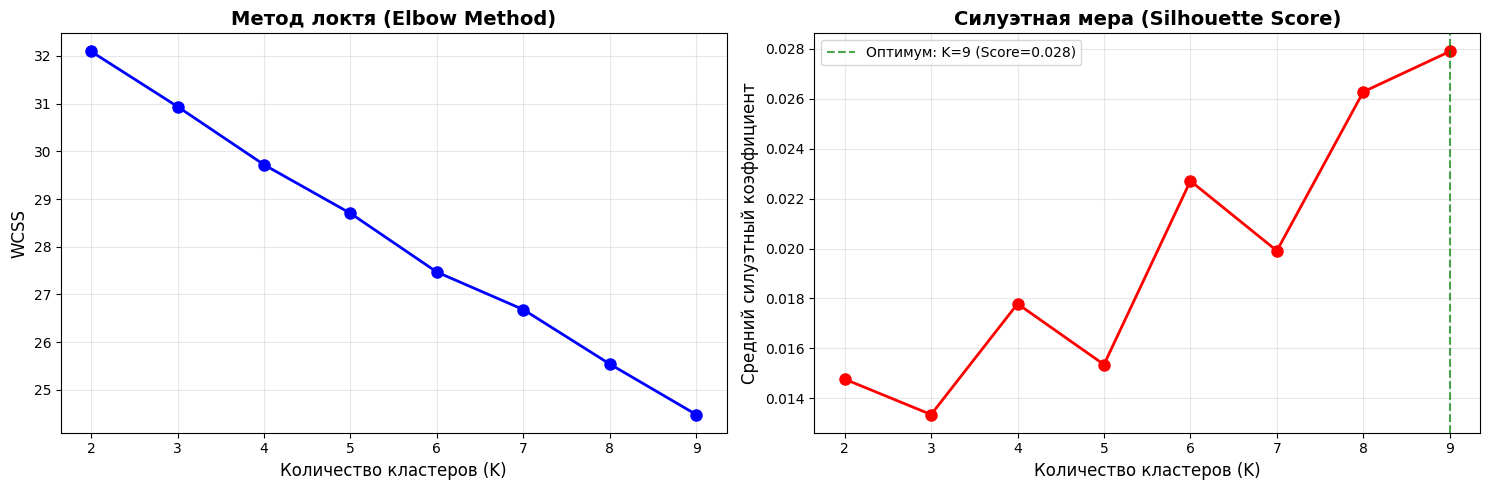

Оптимальное количество кластеров по силуэту: 9


In [7]:
wcss = []
silhouette_scores = []
K_range = range(2, 10)  # Меньший диапазон из-за размера датасета

print("Расчет метрик для разных K...")
for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(tfidf_matrix)
    wcss.append(kmeans.inertia_)
    
    silhouette_avg = silhouette_score(tfidf_matrix, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"  K={k}: WCSS={kmeans.inertia_:.2f}, Silhouette={silhouette_avg:.4f}")

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Метод локтя
ax1.plot(K_range, wcss, 'bo-', linewidth=2, markersize=8)
ax1.set_title('Метод локтя (Elbow Method)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Количество кластеров (K)', fontsize=12)
ax1.set_ylabel('WCSS', fontsize=12)
ax1.grid(True, alpha=0.3)

# Силуэтная мера
ax2.plot(K_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_title('Силуэтная мера (Silhouette Score)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Количество кластеров (K)', fontsize=12)
ax2.set_ylabel('Средний силуэтный коэффициент', fontsize=12)
ax2.grid(True, alpha=0.3)

best_k_silhouette = K_range[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)
ax2.axvline(x=best_k_silhouette, color='green', linestyle='--', alpha=0.7, 
            label=f'Оптимум: K={best_k_silhouette} (Score={best_score:.3f})')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Оптимальное количество кластеров по силуэту: {best_k_silhouette}")


## Классификация текстов


In [8]:
# Разделение выборки
X_train, X_test, y_train, y_test = train_test_split(
    df['tokenize_text'], 
    df['topic_nmf'], 
    test_size=0.3, 
    random_state=0
)

# Обучаем векторизатор на тренировочной выборке
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)


Train TF-IDF shape: (28, 4434)
Test TF-IDF shape: (12, 4434)


### 1. Логистическая регрессия


In [9]:
model_lr = LogisticRegression()
model_lr.fit(X_train_tfidf, y_train)
y_pred_lr = model_lr.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_lr))


              precision    recall  f1-score   support

           0       0.70      1.00      0.82         7
           1       1.00      0.50      0.67         2
           2       1.00      0.50      0.67         2
           4       0.00      0.00      0.00         1

    accuracy                           0.75        12
   macro avg       0.68      0.50      0.54        12
weighted avg       0.74      0.75      0.70        12



### 2. Случайный лес


In [10]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train_tfidf, y_train)
y_pred_rf = model_rf.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.56      0.71      0.62         7
           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         0
           4       0.00      0.00      0.00         1

    accuracy                           0.42        12
   macro avg       0.11      0.14      0.12        12
weighted avg       0.32      0.42      0.36        12



### 3. Метод ближайших соседей (KNN)


In [11]:
model_knn = KNeighborsClassifier()
model_knn.fit(X_train_tfidf, y_train)
y_pred_knn = model_knn.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_knn))


              precision    recall  f1-score   support

           0       1.00      0.57      0.73         7
           1       0.50      1.00      0.67         2
           2       0.67      1.00      0.80         2
           4       1.00      1.00      1.00         1

    accuracy                           0.75        12
   macro avg       0.79      0.89      0.80        12
weighted avg       0.86      0.75      0.75        12



## Сохранение лучшей модели и векторизатора


In [12]:
# Сохраняем Random Forest классификатор и векторизатор в pkl
with open('model_rf.pkl', 'wb') as f:
    pickle.dump(model_rf, f)

with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print("Модели успешно сохранены в model_rf.pkl и vectorizer.pkl")


Модели успешно сохранены в model_rf.pkl и vectorizer.pkl


## Верификация классификатора на тестовых текстах статей


In [13]:
def predict_topic(text):
    text = fun_punctuation_text(text)
    text = fun_lemmatizing_text(text)
    text = fun_tokenize(text)
    text_vectorized = vectorizer.transform([text])
    prediction = model_rf.predict(text_vectorized)
    probabilities = model_rf.predict_proba(text_vectorized)
    return prediction[0], probabilities[0]

# Получим три случайных текста из датасета
samples = df['corpus'].head(3).tolist()

for i, t in enumerate(samples, 1):
    pred, probs = predict_topic(t)
    print(f"Тест {i}: {t[:100]}...")
    print(f"  Предсказанный класс: {pred}")
    print(f"  Вероятности: {probs.round(3)}")
    print()


Тест 1: Нейросети-Художники. ChatGPT в этой роли Искусственный интеллект, Знания — лучшая инвестиция Обзор Н...
  Предсказанный класс: 4
  Вероятности: [0.16 0.04 0.09 0.   0.71]

Тест 2: Меня раздражает, как объясняют асинхронность Python*, Go*, Для IO-bound!, Скрытый текст, Для не гофе...
  Предсказанный класс: 2
  Вероятности: [0.12 0.06 0.77 0.01 0.04]

Тест 3: Когда «просто проведи кастдев» — худший совет Управление продуктом*, Искусственный интеллект, Исслед...
  Предсказанный класс: 0
  Вероятности: [0.65 0.16 0.08 0.05 0.06]

